| **ID**| **Name**| 
|-|-|
| 22280075     | Huynh Thao Quynh  | 
| 22280091 | Nguyen Ngoc Thanh Thu  | 

# **Final Project**

## **GIỚI THIỆU**

Trong thời đại thông tin lan truyền nhanh qua internet và mạng xã hội, việc phân biệt giữa tin thật và tin giả trở thành một thách thức lớn. Tin giả không chỉ gây nhầm lẫn mà còn ảnh hưởng tiêu cực đến niềm tin xã hội và dư luận, đặc biệt nguy hiểm trong các tình huống như đại dịch hay xung đột. Từ góc độ NLP, phát hiện tin giả là một bài toán phức tạp, đòi hỏi các kỹ thuật học máy, học sâu và mô hình hiện đại như Transformer có khả năng phân tích ngữ nghĩa và ngữ cảnh hiệu quả.

**Mục tiêu dự án**: hướng đến việc xây dựng mô hình phân loại tin thật và tin giả bằng cách áp dụng các phương pháp học máy trên hai tập dữ liệu: `MisinfoSuperset_FAKE.csv` và `MisinfoSuperset_TRUE.csv`. Mục tiêu là phát triển mô hình chính xác, đáng tin cậy, đánh giá qua các chỉ số như accuracy, precision, recall và F1-score, tuân theo quy trình học máy đầy đủ từ tiền xử lý đến đánh giá hiệu suất.


## **DATASET**

Bộ dữ liệu gốc được trích xuất từ nghiên cứu của:

> Ahmed, H., Traore, I., & Saad, S. (2017). "Detection of Online Fake News Using N-Gram Analysis and Machine Learning Techniques" (Springer LNCS 10618)

Tệp [`DataSet_Misinfo_TRUE.csv`](https://drive.google.com/file/d/1BhaOQU5wYDL8IxOzgvZM-IlgYfJf3HFD/view)

- Nguồn: Các hãng truyền thông uy tín như Reuters, The New York Times, The Washington Post, v.v.

- Nhãn: Gán nhãn `1` để biểu thị bài viết là tin thật.

Tệp [`DataSet_Misinfo_FAKE.csv`](https://drive.google.com/file/d/1aA9o8PJ-9gYAcLaaxLmXUrxlrHtArlrh/view)

- Nguồn: Các website cực hữu tại Mỹ như Redflag Newsdesk, Breitbart, Truth Broadcast Networ và một phần từ tập dữ liệu công khai của Ahmed et al. (2017) trong nghiên cứu về phân tích N-Gram và học máy.

- Nhãn: Gán nhãn `0` để biểu thị bài viết là tin giả.

## **Phương pháp tiếp cận**

Dự án áp dụng quy trình chuẩn trong lĩnh vực học máy để giải quyết bài toán phân loại tin giả, bao gồm các bước: xử lý dữ liệu, phân tích khám phá dữ liệu (EDA) để hiểu rõ đặc trưng của tập dữ liệu, sau đó tiến hành phân tích dữ liệu để hiểu rõ đặc trưng của tập dữ liệu. Tiếp theo, áp dụng nhiều phương pháp từ truyền thống đến hiện đại như TF-IDF, SVM, mô hình tuần tự (LSTM, BiLSTM), và transformer (BERT) được triển khai để tìm ra giải pháp hiệu quả nhất cho bài toán. Cuối cùng, các mô hình được đánh giá thông qua các chỉ số chuẩn như accuracy, precision, recall và F1-score nhằm so sánh và lựa chọn phương pháp hiệu quả nhất cho bài toán phát hiện tin giả.


---

## **WORK FLOW**

[01. Load Data and Preprocessing](#01-load-data-and-preprocessing)

[02. EDA - Exploratory Data Analysis](#02-eda)

[03. Prepare Data and Setup for Model](#03-prepare-data-and-setup-for-model)

[04. Machine Learning Model](#04-machine-learning-model)

[05 Deep Learning Model](#05-deep-learning-model)

&nbsp;&nbsp;&nbsp;&nbsp;[5.1. LSTM](#51-lstm)

&nbsp;&nbsp;&nbsp;&nbsp;[5.2. BiLSTM](#52-bilstm)

&nbsp;&nbsp;&nbsp;&nbsp;[5.3. CNN - BiLSTM](#53-cnn---bilstm)

[06. Transformer Model](#06-transformer)

&nbsp;&nbsp;&nbsp;&nbsp;[6.1. Bert Model](#61-bert-model)

&nbsp;&nbsp;&nbsp;&nbsp;[6.2. RoBERTa Model](#62-roberta-model)

&nbsp;&nbsp;&nbsp;&nbsp;[6.3. XLNet Model](#63-xlnet-model)

[07. Evaluation and Comparison](#7-evaluation-and-comparison)

---

# **OUR PIPELINE**

In [1]:
# Reproducibility
import random
import re
import html
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

# Set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plotting Libraries (EDA trực quan)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer
from bs4 import BeautifulSoup
from textblob import TextBlob

# Sklearn / ML
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, Conv1D, MaxPooling1D,
    Bidirectional, LSTM, Dropout, Dense
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# PyTorch / Transformers
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    RobertaTokenizer,
    AutoConfig, 
    AutoModelForSequenceClassification,
    XLNetTokenizer,
)

# Ignore warnings
warnings.filterwarnings("ignore")

2025-06-19 10:19:37.255405: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750328377.413766      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750328377.455704      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## **01. Load Data and Preprocessing**

In [2]:
# Load dataset
fake_data = pd.read_csv('dataset_misinfo/DataSet_Misinfo_FAKE.csv')
real_data = pd.read_csv('dataset_misinfo/DataSet_Misinfo_TRUE.csv')

# Drop unnecessary columns and assign labels
fake_data = fake_data.drop(columns=['Unnamed: 0'])
real_data = real_data.drop(columns=['Unnamed: 0'])
fake_data['label'] = 0
real_data['label'] = 1

# Combine real and fake data 
df = pd.concat([real_data, fake_data], axis=0)
df.reset_index(drop=True, inplace=True)
df.sample(7)

,text,label
60915,ZeroHedge.com ALL CONTENT ON 'SGTREPORT.COM' A...,0
43099,As soon as news broke of notorious hatemonger ...,0
59302,"When I was reading the news this morning, I di...",0
29057,"NAIROBI, Kenya — A suicide bomb rocked the ...",1
68003,Email \nIt’s not exactly breaking news that on...,0
1182,A U.S. judge on Tuesday blocked President Dona...,1
58619,"Rusia, China y Arabia Saudita ponen en jaque l...",0


In [3]:
# Display dataset shape
print(f"Dataset shape: {df.shape}")

# Display label distribution
label_counts = df['label'].value_counts()
print(f"\nLabel distribution:\nReal (1): {label_counts[1]}\nFake (0): {label_counts[0]}")

# Check for missing values
missing = df.isnull().sum()
total_missing = missing.sum()
print("\nMissing values per column:")
print(missing)

if total_missing > 0:
    print(f"\nDropping rows with missing values...")
    df = df.dropna().reset_index(drop=True)
    print(f"New dataset shape (after drop NaN): {df.shape}")
else:
    print("\nNo missing values found.")

# Function to check for presence of HTML tags
def contains_html_tags(text):
    html_pattern = r'<[^>]+>'
    return bool(re.search(html_pattern, text))

# Check for duplicates and HTML tags
num_duplicates = df.duplicated().sum()
num_html = df['text'].apply(contains_html_tags).sum()

print(f"\nNumber of duplicate rows: {num_duplicates}")
if num_duplicates > 0:
    print(f"Dropping duplicates...")
    df = df.drop_duplicates()
    print(f"New dataset shape (after drop dup): {df.shape}")
else:
    print("\nNo duplicates found.")

print(f"\nNumber of rows containing HTML tags: {num_html}")

Dataset shape: (78617, 2)

Label distribution:
Real (1): 34975
Fake (0): 43642

Missing values per column:
text     29
label     0
dtype: int64

Dropping rows with missing values...
New dataset shape (after drop NaN): (78588, 2)

Number of duplicate rows: 9984
Dropping duplicates...
New dataset shape (after drop dup): (68604, 2)

Number of rows containing HTML tags: 202


Ở bước này, dữ liệu văn bản được làm sạch và chuẩn hóa nhằm phục vụ cho các loại mô hình khác nhau:

- **Làm sạch văn bản:** Tách riêng 2 hàm xử lý văn bản:

  - `clean_text_ml`: làm sạch phục vụ mô hình truyền thống (loại bỏ stopword, stemming,...). Những bước này giúp giảm nhiễu và số chiều của không gian đặc trưng.

  - `clean_text_transformer`: giữ cấu trúc phù hợp cho các mô hình transformer (giữ nguyên từ gốc, bỏ HTML, URL, ký tự đặc biệt,...) vì các mô hình transformer đã được pretrain dựa trên tự vựng cụ thể, phụ thuộc vào ngữ cảnh và quan hệ giữa các từ trong câu.

- **Trích xuất đặc trưng cảm xúc và hình thái học:**  

  - Dùng **VADER** để lấy điểm cảm xúc compound từ văn bản.

  - Dùng **TextBlob** để trích xuất polarity (tích cực/tiêu cực) và subjectivity (mức độ chủ quan).

- **Tính độ dài bài viết:** Sử dụng để hỗ trợ cho EDA hoặc làm feature phụ trợ trong mô hình.

Sau bước này, dữ liệu đã sẵn sàng để phân tích EDA và huấn luyện mô hình.

In [4]:
# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('vader_lexicon')

# Initialize stopwords, stemmer, and sentiment analyzer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Get compound sentiment score using VADER"""
    return sia.polarity_scores(text)['compound']

def get_textblob_sentiment(text):
    """Get polarity and subjectivity using TextBlob"""
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

def clean_text_transformer(text):
    """
    Preprocess text for transformer models.

    Removes escape characters, HTML tags, URLs, repeated special characters,
    and normalizes whitespace.
    """
    text = re.sub(r'[\t\r\n]', ' ', text)
    if re.search(r'<[^>]+>', text):
        text = BeautifulSoup(text, "html.parser").get_text()

    text = re.sub(r'(https?://)([^/\s]+)([^\s]*)', r'\2', text)
    text = re.sub(r'[_~+\-]{2,}', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

def clean_text_ML(text):
    """
    Preprocessing for traditional ML models

    Convert to lowercase, remove HTML, URLs, and excess characters
    Remove stopwords and apply stemming
    """
    text = str(text).lower()
    if re.search(r'<[^>]+>', text):
        text = BeautifulSoup(text, "html.parser").get_text()
    text = html.unescape(text)                                 
    text = re.sub(r'(https?://)([^/\s]+)([^\s]*)', ' ', text)
    text = re.sub(r'[_~+\-]{2,}', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    filtered = [stemmer.stem(w) for w in tokens
                if w.isalnum() and w not in stop_words]       
    
    return ' '.join(filtered)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Administra\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [5]:
df['clean_text_trans'] = df['text'].apply(clean_text_transformer)
df['clean_text_ml'] = df['text'].apply(clean_text_ML)

df['article_length'] = df['clean_text_ml'].apply(lambda x: len(x.split()))
df['sentiment'] = df['clean_text_ml'].apply(get_sentiment)
df['textblob_sentiment'], df['textblob_subjectivity'] = zip(*df['clean_text_ml'].apply(get_textblob_sentiment))
df.head()

,text,label,clean_text_trans,clean_text_ml,article_length,sentiment,textblob_sentiment,textblob_subjectivity
0,The head of a conservative Republican faction ...,1,The head of a conservative Republican faction ...,head conserv republican faction us congress vo...,431,0.9702,0.022500,0.408500
1,Transgender people will be allowed for the fir...,1,Transgender people will be allowed for the fir...,transgend peopl allow first time enlist us mil...,222,0.5719,0.239352,0.518981
2,The special counsel investigation of links bet...,1,The special counsel investigation of links bet...,special counsel investig link russia presid 20...,250,0.5423,0.220640,0.365002
3,Trump campaign adviser George Papadopoulos tol...,1,Trump campaign adviser George Papadopoulos tol...,trump campaign advis georg papadopoulo told au...,218,0.8979,0.104685,0.278385
4,President Donald Trump called on the U.S. Post...,1,President Donald Trump called on the U.S. Post...,presid donald trump call us postal servic frid...,494,0.8979,0.003611,0.365556


In [6]:
index = 500

print("-" * 50)
print(f"TEST OUTPUT (index {index})".center(50))
print("-" * 50)

print(f"\n[1] Origin Text:\n")
print("   *", df['text'][index])

print(f"\n[2] Cleaned Text for ML model:\n")
print("   *", df['clean_text_ml'][index])

print(f"\n[3] Cleaned Text for Transformer model:\n")
print("   *", df['clean_text_trans'][index])

print("-" * 50)


--------------------------------------------------
             TEST OUTPUT (index 500)              
--------------------------------------------------

[1] Origin Text:

   * The U.S. Senate Budget Committee voted along party lines on Tuesday to send a Republican tax bill to the full Senate for a vote. The 12-to-11 vote “moves us one step closer to a simpler, fairer, and more transparent tax system,” Budget Committee Chairman Mike Enzi said in a statement.  The full Senate is expected to begin debating the tax bill and vote on it sometime this week. The Republican-controlled House of Representatives has already passed its version of a package of tax cuts.

[2] Cleaned Text for ML model:

   * us senat budget committe vote along parti line tuesday send republican tax bill full senat vote 12to11 vote us one step closer simpler fairer transpar tax budget committe chairman mike enzi said statement full senat expect begin debat tax bill vote sometim week republicancontrol hous repres alre

In [7]:
# Shuffle the dataset randomly to avoid order bias
df1 = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset shape:", df1.shape)

Dataset shape: (68604, 8)


In [ ]:
# SAVE DATA 
df1.to_parquet("dataset_misinfo/data_after_preprocess.parquet", index=False)

## **02. EDA**

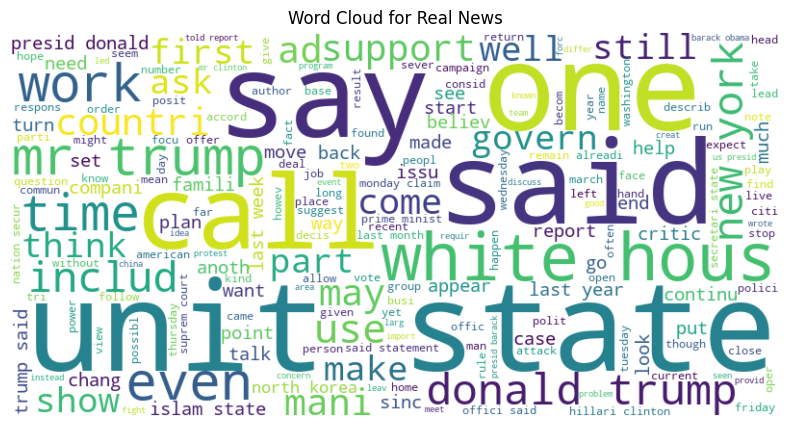

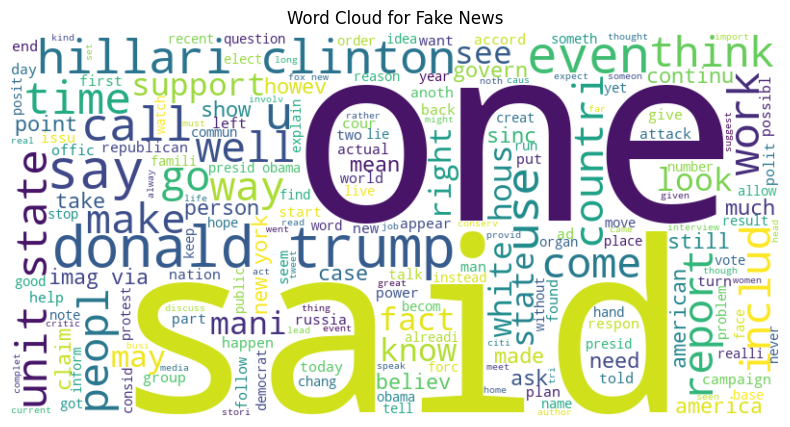

In [10]:
def plot_word_cloud(data, title):
    text_data = ' '.join(data.astype(str))
    if not text_data.strip():  
        print(f"No text data available for {title}")
        return
    
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate word clouds for Real (label=1) and Fake (label=0) news
plot_word_cloud(df1[df1['label'] == 1]['clean_text_ml'], 'Word Cloud for Real News')
plot_word_cloud(df1[df1['label'] == 0]['clean_text_ml'], 'Word Cloud for Fake News')

Hai biểu đồ đám mây từ (word cloud) cho thấy sự khác biệt rõ rệt giữa các từ khóa phổ biến trong tin tức thật (Word Cloud for Real News) và tin tức giả mạo (Word Cloud for Fake News)

**1. Word Cloud for Real News**

- **Từ khóa nổi bật**: "said", "one", "state", "call", "trump", "white", "house", "time", "mr", "include" chiếm ưu thế, với kích thước lớn hơn, cho thấy tần suất xuất hiện cao.

- **Đặc điểm**:

    - Từ vựng mang tính chính thức, báo chí chuyên nghiệp, và tuyên bố chính thức ("said", "state", "include") phản ánh văn phong của các bài viết báo chí truyền thống. 

    - Sự hiện diện của các địa danh và tổ chức: "united states", "white house", "new york", cho thấy nội dung tập trung vào tin tức chính trị - xã hội thực tế.

    - Ít mang tính cảm xúc: Không thấy nhiều từ mang tính phán xét, cảm xúc mạnh hay cực đoan.

**2. Word Cloud for Fake News**

- Từ khóa nổi bật: "one", "said", "hillary", "clinton", "trump", "state", "support", "make", "right", "think".

- **Đặc điểm**:

    - Nội dung cá nhân và thiên kiến hơn ("hillary", "clinton", "right", "attack" xuất hiện nhiều), cho thấy nội dung mang thiên hướng chính trị, cá nhân hóa và có thể chứa định kiến.

    - Nhiều từ gây tranh cãi/cảm xúc: "attack", "fake", "claim" thường được dùng để kích động hoặc đưa ra quan điểm cực đoan.

    - Tập trung vào một vài nhân vật cụ thể: "hillary clinton", "trump" xuất hiện nổi bật hơn hẳn, thể hiện xu hướng tập trung cá nhân hóa nội dung trong tin giả.

In [4]:
# Count the number of articles by label
article_count = df1['label'].value_counts().reset_index()
article_count.columns = ['label', 'count']

# Map labels 0, 1 to Fake, Real
article_count['label'] = article_count['label'].map({0: 'Fake', 1: 'Real'})

print("Number of articles by label:")
print(article_count) 

# Count the number of real and fake news articles
label_counts = df1['label'].value_counts()

label_df = pd.DataFrame({'label': label_counts.index, 'count': label_counts.values})
label_df['label'] = label_df['label'].map({0: 'Fake', 1: 'Real'})  

fig = make_subplots(
    rows=1, 
    cols=2, 
    specs=[[{'type': 'pie'}, {'type': 'bar'}]],
    subplot_titles=("Pie Chart of News Labels", "Bar Plot of News Labels"),
    horizontal_spacing=0.15 
)

# Pie Chart
pie_chart = go.Pie(
    labels=label_df['label'], 
    values=label_df['count'], 
    hole=0.4,
    marker_colors=['#4ECDC4', '#FF6B6B'], 
    textinfo='percent+label',
    hoverinfo='label+percent+value'
)
fig.add_trace(pie_chart, row=1, col=1)

# Bar Plot
bar_plot = go.Bar(
    x=label_df['label'], 
    y=label_df['count'], 
    marker_color=['#4ECDC4', '#FF6B6B'],
    text=label_df['count'],
    textposition='outside'
)
fig.add_trace(bar_plot, row=1, col=2)

fig.update_layout(
    title=dict(
        text='Distribution of Real and Fake News',
        font=dict(size=20, color='#333333'),
        x=0.5,
        xanchor='center'
    ),
    font=dict(family='Arial', size=14, color='#333333'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=True,
    legend=dict(
        title='News Type',
        x=0.85,
        y=0.9
    ),
    height=600,
    width=1100,  
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.update_yaxes(
    title_text='Number of Articles',
    showgrid=True,
    gridcolor='lightgrey',
    gridwidth=1,
    tickformat=',',
    title_font=dict(size=16),
    tickfont=dict(size=14),
    range=[0, max(label_df['count']) * 1.6],
    row=1, col=2
)
fig.update_xaxes(
    title_text='News Type',
    title_font=dict(size=16),
    tickfont=dict(size=14),
    row=1, col=2
)

fig.show()

Number of articles by label:
  label  count
0  Real  34526
1  Fake  34078


**1. Phân bố dữ liệu gần như cân bằng**

- Chênh lệch giữa hai lớp chỉ 448 bài viết (~1.3%).

- Điều này rất tốt cho việc huấn luyện mô hình, vì mô hình sẽ không bị bias (thiên lệch) do dữ liệu mất cân bằng.

**2. Ý nghĩa trong huấn luyện mô hình**

- Không cần kỹ thuật cân bằng dữ liệu như oversampling (tăng dữ liệu lớp thiểu số) hay undersampling (giảm lớp đa số).

- Cho phép mô hình học phân biệt tin thật – giả dựa trên đặc trưng nội dung, không bị ảnh hưởng bởi tỷ lệ mẫu, tránh tình trạng mô hình dự đoán sai lệch về lớp đa số, phục vụ tốt cho các bài toán phân loại (classification).

In [14]:
# Calculate the average article length by label
article_length_avg = df1.groupby('label')['article_length'].mean().reset_index()
article_length_avg.columns = ['label', 'avg_length']

# Map labels 0, 1 to Fake, Real
article_length_avg['label'] = article_length_avg['label'].map({0: 'Fake', 1: 'Real'})

print("Average article length by label:")
print(article_length_avg)

# Create a bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=article_length_avg['label'],
    y=article_length_avg['avg_length'],
    marker_color=['#FF6B6B', '#4ECDC4'],  
    text=article_length_avg['avg_length'], 
    textposition='outside',
    texttemplate='%{text:.1f}', 
    width=0.3, 
    marker_line=dict(color='#000000', width=1)  
))

fig.update_layout(
    title=dict(
        text='Average Article Length by News Type',
        font=dict(size=20, color='#333333'),
        x=0.5,
        xanchor='center'
    ),
    xaxis_title='News Type',
    yaxis_title='Average Length (words)',
    font=dict(family='Arial', size=14, color='#333333'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        showgrid=False,
        title_font=dict(size=16),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgrey',
        gridwidth=1,
        title_font=dict(size=16),
        tickfont=dict(size=14),
        range=[0, max(article_length_avg['avg_length']) * 1.2]  
    ),
    bargap=0.05,  
    showlegend=False,
    margin=dict(l=50, r=50, t=80, b=50),
    height=500
)

fig.show()

Average article length by label:
  label  avg_length
0  Fake  235.010476
1  Real  298.769073


**1. Real News dài hơn Fake News**

- Bài viết thật có xu hướng dài hơn so với bài viết giả.

- Điều này hợp lý vì các nguồn báo chí chính thống (như Reuters, The New York Times) thường cung cấp thông tin chi tiết, được kiểm chứng kỹ lưỡng, bao gồm các thông tin nền, trích dẫn và phân tích sâu.

**2. Fake News có xu hướng ngắn và súc tích hơn**

- Tin giả thường được viết ngắn gọn, tiêu đề giật gân, nhằm nhanh chóng thu hút sự chú ý hoặc kích thích cảm xúc người đọc.

- Các bài viết này có thể cố tình tránh đi vào chi tiết, giảm khả năng kiểm chứng nội dung.

In [15]:
# Calculate mean, max, and min sentiment scores for each label
mean_sentiment = df1.groupby('label')['sentiment'].mean().reset_index()
max_sentiment = df1.groupby('label')['sentiment'].max().reset_index()
min_sentiment = df1.groupby('label')['sentiment'].min().reset_index()

summary_sentiment = pd.merge(mean_sentiment, max_sentiment, on='label', suffixes=('_mean', '_max'))
summary_sentiment = pd.merge(summary_sentiment, min_sentiment, on='label')
summary_sentiment.rename(columns={'sentiment': 'sentiment_min'}, inplace=True)

for index, row in summary_sentiment.iterrows():
    print(f"Label: {row['label']}, Mean Sentiment: {row['sentiment_mean']:.2f}, Max Sentiment: {row['sentiment_max']:.2f}, Min Sentiment: {row['sentiment_min']:.2f}")

# Create a violin plot for sentiment scores
fig = px.violin(df1, 
                 x='label', 
                 y='sentiment', 
                 box=True, 
                 points='all', 
                 title='Sentiment Polarity Distribution by Label',
                 color='label',  # Color by label
                 color_discrete_sequence=['#FF6B6B', '#4ECDC4'])  # Custom colors

fig.update_traces(meanline_visible=True)  
fig.update_layout(yaxis_title='Sentiment Score',
                  xaxis_title='News Category',
                  legend_title='Label',
                  legend=dict(x=0.85, y=0.9))  

fig.show()

Label: 0.0, Mean Sentiment: -0.06, Max Sentiment: 1.00, Min Sentiment: -1.00
Label: 1.0, Mean Sentiment: 0.02, Max Sentiment: 1.00, Min Sentiment: -1.00


**Cảm xúc của Fake News có xu hướng tiêu cực hơn**
  
- Giá trị trung bình là âm (-0.06) cho thấy nhiều bài viết giả có xu hướng mang tính tiêu cực hơn, có thể mang tính công kích, giật gân, hoặc gây hoang mang.

**Real News gần trung tính hoặc hơi tích cực**

- Với điểm trung bình là +0.02, nội dung của tin thật nhìn chung có thiên hướng trung lập hoặc mô tả khách quan, điều này phù hợp với văn phong báo chí chuyên nghiệp.

**Cả hai loại đều có phân bố rộng**

- Dải sentiment kéo dài từ -1 đến 1 cho cả hai loại, nghĩa là có sự đa dạng cảm xúc trong cả tin thật lẫn tin giả.

- Tuy nhiên, biểu đồ violin cho Fake News phình to ở các cực trị, thể hiện nhiều bài viết có cảm xúc rất mạnh (rất tích cực hoặc rất tiêu cực), trong khi Real News có xu hướng tập trung gần vùng trung tâm hơn.

$\rightarrow$ Sentiment score có thể là một feature hữu ích, giúp mô hình nhận biết xu hướng cảm xúc bất thường trong Fake News. Tuy nhiên, nó không đủ mạnh để phân biệt hoàn toàn, nên nên dùng kết hợp với các đặc trưng khác như từ vựng, độ dài, hoặc cấu trúc ngữ pháp.

In [17]:
# Function to get top N words, excluding stopwords
def get_top_n_words(corpus, n=10):
    words = ' '.join(corpus).split()
    words = [word for word in words if word.isalpha() and word.lower() not in stop_words]
    common_words = Counter(words)
    return common_words.most_common(n)

# Function to plot top N words 
def plot_top_n_words(data, title, n=10, base_color='#000000', highlight_color='#000000'):
    top_words = get_top_n_words(data['clean_text_ml'], n)
    if not top_words:  
        print(f"No significant words to plot for {title}")
        return
    
    words, counts = zip(*top_words)
    
    counts = list(counts)
    words = list(words)

    print(f"Top words for {title}:")
    for word, count in zip(words, counts):
        print(f"{word}: {count}")
    
    max_count_index = counts.index(max(counts))

    colors = [highlight_color if i == max_count_index else base_color for i in range(len(counts))]

    fig = px.bar(x=words, y=counts, 
                 title=title, 
                 labels={'x': 'Words', 'y': 'Counts'},
                 color=words,  
                 color_discrete_map={word: color for word, color in zip(words, colors)},
                 text=counts, 
                 text_auto=True)  

    fig.update_traces(textposition='outside')
    
    fig.update_layout(
        title=dict(text=title, 
                   font=dict(size=20, color='#333333'), 
                   x=0.5, 
                   xanchor='center'),
        xaxis_title='Words',
        yaxis_title='Counts',
        font=dict(family='Arial', size=14, color='#333333'),
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(
            showgrid=False, 
            title_font=dict(size=16),
            tickfont=dict(size=14),
            tickangle=45  
        ),
        yaxis=dict(
            showgrid=True, 
            gridcolor='lightgrey', 
            gridwidth=1,
            title_font=dict(size=16),
            tickfont=dict(size=14)
        ),
        showlegend=False,
        margin=dict(l=50, r=50, t=80, b=50),
        height=500
    )
    
    fig.show()

real_base_color = '#4ECDC4'  
real_highlight_color = '#2A7C73' 
fake_base_color = '#FF6B6B'  
fake_highlight_color = '#B53030'

In [18]:
# Plot top 10 words for Real and Fake news 
plot_top_n_words(df1[df1['label'] == 1], 'Top 10 Words in Real News', n=10, 
                 base_color=real_base_color, highlight_color=real_highlight_color)
plot_top_n_words(df1[df1['label'] == 0], 'Top 10 Words in Fake News', n=10, 
                 base_color=fake_base_color, highlight_color=fake_highlight_color)

Top words for Top 10 Words in Real News:
said: 166378
trump: 75739
mr: 70400
state: 60537
would: 56008
presid: 47034
us: 45676
year: 39836
one: 39010
new: 38366


Top words for Top 10 Words in Fake News:
trump: 81548
peopl: 37759
us: 36534
said: 35349
one: 34873
state: 33808
would: 33419
clinton: 30606
presid: 30500
like: 29915


**Điểm chung giữa hai loại**

- Một số từ xuất hiện nhiều trong cả hai tập như: “trump”, “said”, “us”, “state”, “would”, “presid”, “one”. Cho thấy hai loại tin tức đều đề cập đến các chủ đề tương tự như chính trị, quốc gia, nhân vật công chúng.

**Khác biệt chính**
|Real News	| Fake News |
| - | - |
|“said” là từ phổ biến nhất – phản ánh phong cách trích dẫn trong báo chí truyền thống.	 | “trump” là từ phổ biến nhất – thể hiện sự tập trung chủ yếu vào cá nhân, thường là để phê phán hay tuyên truyền.|
|Có từ “mr” mang tính trang trọng.	| Có từ “peopl” (đã được stemming từ “people”) cho thấy văn phong gần gũi hoặc đại chúng. |
|“year, new” → đề cập thời gian hoặc bối cảnh sự kiện.	| “clinton, like” → tập trung cá nhân và cảm tính nhiều hơn. |

**Ý nghĩa phân loại**

- Fake News có xu hướng tập trung vào cá nhân hóa và từ ngữ cảm tính hơn.

- Real News ưu tiên trình bày trung lập và có cấu trúc chuyên nghiệp hơn (nhiều trích dẫn, danh xưng trang trọng).

## **03. Prepare Data and Setup for Model**

#### **Split data**

- Sau khi dữ liệu đã được làm sạch và tạo đặc trưng, bước tiếp theo là chuẩn bị dữ liệu để huấn luyện và đánh giá mô hình. Việc chia tách dữ liệu hợp lý sẽ đảm bảo mô hình được huấn luyện tốt, không overfit, và có thể tổng quát hóa tốt trên dữ liệu chưa từng thấy.

- Cụ thể, dữ liệu được chia thành ba phần:

    - **Training set (80%)**: dùng để huấn luyện mô hình.

    - **Validation set (10%)**: dùng để tinh chỉnh siêu tham số và theo dõi overfitting, đảm bảo kết quả khách quan.

    - **Test set (10%)**: dùng để đánh giá hiệu suất cuối cùng của mô hình trên dữ liệu chưa thấy.

- Việc tách dữ liệu sử dụng kỹ thuật `stratified splitting` để đảm bảo phân phối nhãn giữa các tập là đồng đều (số lượng bài viết tin thật và tin giả phân bố đều).
 
#### **Evaluate function**

- Ngoài ra, xây dựng thêm các hàm hỗ trợ đánh giá mô hình, giúp chuẩn hóa quá trình đánh giá tất cả các mô hình sau này.

    - Thực hiện đánh giá mô hình bằng các chỉ số (Accuracy, Precision, Recall, F1-score), hiển thị ma trận nhầm lẫn (Confusion Matrix) để trực quan hóa hiệu quả phân loại và in classification report.

    - Trực quan hóa hàm mất mát (training và validation loss) theo từng epoch, hỗ trợ quá trình đánh giá mô hình, giúp sớm phát hiện overfitting.

> Bước chuẩn bị này đảm bảo tính nhất quán, công bằng cho việc huấn luyện và đánh giá các mô hình, dễ so sánh hiệu quả giữa các mô hình khác nhau và đảm bảo độ tin cậy trong kết luận cuối cùng.

In [3]:
X = df1.drop(columns=['label'])
y = df1['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2, 
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)
print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

Train: 54,883  |  Val: 6,860  |  Test: 6,861


In [13]:
def evaluate_model(model_name, y_test, y_pred):
    # Metric
    print(f"--------------- {model_name} Model ---------------")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")
    print(f"Precision: {precision_score(y_test, y_pred):.5f}")
    print(f"Recall: {recall_score(y_test, y_pred):.5f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.5f}")

    # Classification report
    print("\nClassification Report")
    print(classification_report(y_test, y_pred, digits=3))

    print('-'*30)
    print(f"Predict results (ground truth vs predicted)")
    df_pred = pd.DataFrame({
        'y_test': y_test,
        'Predicted': y_pred if ('bert' in model_name or 'xlnet' in model_name) else y_pred.reshape(-1)
    })
    # Xem ngẫu nhiên 10 sample
    display(df_pred.sample(10))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def visualize_loss(model_name, train_loss, val_loss):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title(f'Training vs. Validation Loss - {model_name} Model')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## **04. Machine Learning Model**

Trong phần này, áp dụng các mô hình học máy truyền thống (Linear SVM) để xây dựng hệ thống phân loại tin giả. Mục tiêu là thiết lập một baseline ổn định, đơn giản nhưng đủ mạnh, nhằm làm cơ sở so sánh với các mô hình học sâu và transformer sau này.

#### **Các bước triển khai**

- **Bước 1:** Sử dụng các kỹ thuật vector hóa phổ biến để chuyển đổi văn bản thành đặc trưng số

    - **TF-IDF**: Cân bằng giữa tần suất và độ phân biệt của từ.

    - **Count Vectorizer**: Đếm tần suất từ trực tiếp.

- **Bước 2:** Kết hợp từng vectorizer với LinearSVC - một mô hình phân loại mạnh mẽ và đơn giản, đặc biệt hiệu quả trên các bài toán phân loại văn bản có đặc trưng thưa (sparse features). LinearSVC được cấu hình với `class_weight="balanced"` để xử lý phân bố nhãn không đồng đều.

- **Bước 3:** Thực hiện tìm kiếm lưới siêu tham số `GridSearchCV` trên mỗi pipeline để xác định cấu hình tối ưu nhất dựa trên điểm F1-score. Sau khi xác định pipeline tối ưu dựa trên hiệu suất validation, mô hình được huấn luyện lại trên tập huấn luyện đầy đủ và đánh giá cuối cùng trên tập test.

#### **Đối với bài toán Fake New Detection**

- Việc áp dụng mô hình học máy truyền thống như LinearSVC kết hợp với vectorizer là lựa chọn phù hợp. Tin giả thường sử dụng các từ ngữ giật tít, cấu trúc câu gây kích thích cảm xúc hoặc biểu đạt thiếu trung lập. Những đặc trưng này có thể được nắm bắt tương đối hiệu quả thông qua tần suất và sự kết hợp từ (n-gram) – vốn là thế mạnh của các kỹ thuật vector hóa như TF-IDF và Count Vectorizer.

In [5]:
X_train_txt, X_test_txt, X_val_txt = [
    df['clean_text_ml'] 
    for df in (X_train, X_test, X_val)
]

In [6]:
pipelines = {
    "TFIDF": Pipeline([
        ("vect", TfidfVectorizer(
            stop_words="english",
            strip_accents="unicode",
            sublinear_tf=True
        )),
        ("clf", LinearSVC(class_weight="balanced", random_state=42))
    ]),
    "COUNT": Pipeline([
        ("vect", CountVectorizer(
            stop_words="english",
            strip_accents="unicode"
        )),
        ("clf", LinearSVC(class_weight="balanced", random_state=42))
    ]),
}

param_grids = {
    "TFIDF": {
        "vect__ngram_range": [(1, 1), (1, 2)],
        "vect__min_df": [3, 5],
        "vect__max_df": [0.8, 0.9],
        "clf__C": [0.25, 0.5, 1, 2],
    },
    "COUNT": {
        "vect__ngram_range": [(1, 1), (1, 2)],
        "vect__min_df": [3, 5],
        "vect__max_df": [0.8, 0.9],
        "clf__C": [0.25, 0.5, 1, 2],
    },
}

best_name, best_f1, best_pipe = None, -1, None


for name, pipe in pipelines.items():
    print(f"\n=== GridSearch for {name} ===")
    gs = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="f1",
        verbose=1,
        n_jobs=-1,
    )
    gs.fit(X_train_txt, y_train)

    print("Best CV params:", gs.best_params_)
    print("Best CV F1   :", gs.best_score_)

    val_pred = gs.predict(X_val_txt)
    f1_val   = f1_score(y_val, val_pred)
    acc_val  = accuracy_score(y_val, val_pred)
    print(f"Val Accuracy: {acc_val:.4f} | Val F1: {f1_val:.4f}")
    print(classification_report(y_val, val_pred, digits=4))

    if f1_val > best_f1:
        best_name, best_f1, best_pipe = name, f1_val, gs.best_estimator_

print(f"\nBest on Val: {best_name} | F1 = {best_f1:.4f}")



=== GridSearch for TFIDF ===
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best CV params: {'clf__C': 2, 'vect__max_df': 0.8, 'vect__min_df': 3, 'vect__ngram_range': (1, 2)}
Best CV F1   : 0.9577822483834927
Val Accuracy: 0.9612 | Val F1: 0.9615
              precision    recall  f1-score   support

           0     0.9610    0.9610    0.9610      3408
           1     0.9615    0.9615    0.9615      3452

    accuracy                         0.9612      6860
   macro avg     0.9612    0.9612    0.9612      6860
weighted avg     0.9612    0.9612    0.9612      6860


=== GridSearch for COUNT ===
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best CV params: {'clf__C': 0.25, 'vect__max_df': 0.8, 'vect__min_df': 5, 'vect__ngram_range': (1, 2)}
Best CV F1   : 0.9324519752725511
Val Accuracy: 0.9332 | Val F1: 0.9333
              precision    recall  f1-score   support

           0     0.9283    0.9381    0.9332      3408
           1     0.9382    0.9284  

--------------- SVM Model ---------------
Accuracy: 0.96312
Precision: 0.96377
Recall: 0.96293
F1 Score: 0.96335

Classification Report
              precision    recall  f1-score   support

           0      0.962     0.963     0.963      3408
           1      0.964     0.963     0.963      3453

    accuracy                          0.963      6861
   macro avg      0.963     0.963     0.963      6861
weighted avg      0.963     0.963     0.963      6861

------------------------------
Predict results (ground truth vs predicted)


,y_test,Predicted
47223,1,1
24314,1,1
24527,0,0
43812,1,1
62332,1,1
44103,1,1
3466,1,1
59214,0,0
40165,1,1
60896,1,1


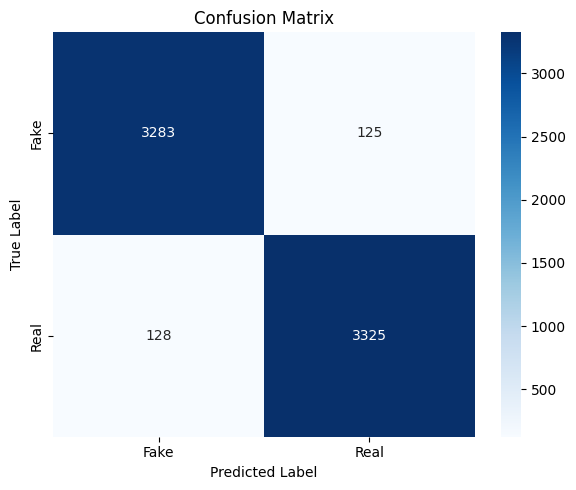

In [9]:
X_train_full_txt = pd.concat([X_train_txt, X_val_txt])
y_train_full     = pd.concat([y_train, y_val])

best_pipe.fit(X_train_full_txt, y_train_full)

y_pred_ml = best_pipe.predict(X_test_txt)

evaluate_model("SVM", y_test, y_pred_ml)

## **05. Deep Learning Model**

In [6]:
X_train_dl, X_test_dl, X_val_dl = [
    df['clean_text_ml'] 
    for df in (X_train, X_test, X_val)
]

### **Analyze rare words**

- Trước khi khởi tạo tokenizer chính thức cho mô hình deep learning, cần thực hiện phân tích tần suất xuất hiện của các từ trong tập training để đánh giá độ phổ biến và quyết định cắt bỏ từ hiếm. Cần tính toán:

    - Tỷ lệ từ hiếm chiếm bao nhiêu phần trăm trong tổng từ vựng.

    - Các từ hiếm này chiếm bao nhiêu phần trăm tần suất sử dụng thực tế trong toàn bộ tập văn bản.

- Việc này giúp xác định ngưỡng để loại bỏ các từ quá hiếm nhằm giảm nhiễu và tối ưu hóa số lượng từ cần học trong embedding layer. Kết quả phân tích sẽ được sử dụng để quyết định giới hạn `vocab_size` cho tokenizer chính, phục vụ cho bước mã hóa và padding dữ liệu ở các bước tiếp theo.

In [7]:
# Analyze rare words in vocabulary
threshold = 4                       # Words appearing fewer than 4 times are considered rare
tmp_tokenizer = Tokenizer()
tmp_tokenizer.fit_on_texts(X_train_dl)

total_words = len(tmp_tokenizer.word_counts)
rare_words = sum(1 for count in tmp_tokenizer.word_counts.values() if count < threshold)
rare_freq = sum(count for count in tmp_tokenizer.word_counts.values() if count < threshold)
total_freq = sum(tmp_tokenizer.word_counts.values())

print(f"% of rare words in vocabulary: {rare_words / total_words * 100:.2f}%")
print(f"Total coverage of rare words: {rare_freq / total_freq * 100:.2f}%")

% of rare words in vocabulary: 77.43%
Total coverage of rare words: 1.81%


### **Setup model**

- Sau khi đã xác định tỷ lệ từ hiếm, tokenizer chính thức được khởi tạo với `num_words` giới hạn ở số lượng từ phổ biến (loại bỏ từ hiếm). Mục tiêu là giảm độ phức tạp của mô hình và tập trung vào các từ có giá trị ngữ nghĩa cao.

- Văn bản trong ba tập (train, validation, test) được mã hóa thành chuỗi số nguyên bằng tokenizer, sau đó được padding về cùng độ dài cố định (MAX_LEN). Việc này giúp đảm bảo dữ liệu đầu vào có cùng kích thước, phù hợp với yêu cầu của các mô hình học sâu.

In [8]:
# Set parameters
MAX_LEN = 300               # Maximum sequence length for padding
latent_dim = 350            # LSTM hidden state dimension
embedding_dim = 300        

# Initialize tokenizer with only frequent words 
vocab_size = total_words - rare_words
tokenizer_dl = Tokenizer(num_words=vocab_size)
tokenizer_dl.fit_on_texts(X_train_dl)

# Sequence & padding
X_train_seq = tokenizer_dl.texts_to_sequences(X_train_dl)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test_dl)
X_val_seq = tokenizer_dl.texts_to_sequences(X_val_dl)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post')

Khởi tạo mô hình cho 3 model khác nhau:

- LSTM 

- BiLSTM

- Kết hợp CNN - BiLSTM

Tất cả mô hình đều bắt đầu bằng tầng Embedding học được, theo sau là các tầng dropout, recurrent hoặc convolutional phù hợp, kết thúc bằng một tầng Dense nhị phân với hàm kích hoạt sigmoid. 

Sau khi mô hình được khởi tạo, tiến hành huấn luyện mô hình. Sử dụng `ModelCheckpoint` để lưu mô hình có hiệu suất validation tốt nhất và áp dụng `EarlyStopping` để tránh overfitting khi validation loss không cải thiện. Theo dõi quá trình huấn luyện trong tối đa 20 epoch với batch size 128.

In [9]:
def init_model(model_name, dropout=0.2, filters=32, kernel_size=5):
    """Function to initialize different DL models"""
    model = Sequential()

    # Embedding layer
    model.add(Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim, input_shape=(MAX_LEN,), trainable=True))
    model.add(Dropout(dropout))
    
    # Choose model architecture
    if model_name == 'lstm':
        model.add(LSTM(latent_dim, return_sequences=False))

    elif model_name == 'bilstm':
        model.add(Bidirectional(LSTM(latent_dim, return_sequences=False)))
    
    elif model_name == 'cnn_bilstm':
        # CNN layer
        model.add(Conv1D(filters, kernel_size, activation='relu', strides=1, padding='same'))
        model.add(MaxPooling1D())

        model.add(Conv1D(filters, kernel_size, activation='relu',  strides=1, padding='same'))
        model.add(MaxPooling1D())

        # BiLSTM layer
        model.add(Bidirectional(LSTM(latent_dim, return_sequences=False)))

    else:
        raise ValueError("Unknown model_name. Choose from: 'lstm', 'bilstm', 'cnn_bilstm'")
    
    # Output layer
    model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    # Compile and print model architecture summary
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()
    return model


In [10]:
def train_and_save_model(model_name, model):
    print(f"\n----- Training {model_name.upper()} -----")

    # Create a unique checkpoint path for each model
    checkpoint_path = f"checkpoint_{model_name}.h5"

    # Callback to save the best model
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True,
        verbose=1
    )

    # Training model
    history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=128,
        callbacks=[checkpoint, early_stopping],
        verbose=2
    )

    return model, history, checkpoint_path


### **5.1. LSTM**

**LSTM và cách khắc phục so với RNN truyền thống**

- **LSTM** (Long Short-Term Memory) là một loại mạng nơ-ron hồi tiếp (Recurrent Neural Network – RNN) được thiết kế để khắc phục điểm yếu của RNN truyền thống trong việc ghi nhớ thông tin dài hạn. 

- RNN học các chuỗi dữ liệu bằng cách sử dụng thông tin từ bước trước để dự đoán bước hiện tại. Tuy nhiên:

    - Khi chuỗi quá dài, gradient có thể bị mất hoặc nổ trong quá trình lan truyền ngược (vanishing/exploding gradient).

    - Điều này khiến RNN khó học được quan hệ phụ thuộc dài hạn trong chuỗi.

- LSTM giải quyết vấn đề trên bằng cách thiết kế thêm cơ chế `cell state` (bộ nhớ) và các `gates` (cổng) để điều khiển dòng thông tin, quyết định thông tin nào cần giữ lại hoặc loại bỏ.

**Đối với bài toán Fake New Detection**

- Trong bài toán phân loại tin giả, dữ liệu đầu vào là các đoạn văn bản – vốn mang tính chuỗi tự nhiên. Các yếu tố như mối quan hệ giữa từ, ngữ cảnh câu, và cấu trúc thông tin có thể kéo dài qua nhiều từ hoặc câu.

    $\rightarrow$ Việc áp dụng LSTM là phù hợp do nó có khả năng nắm bắt được mối quan hệ dài hạn trong văn bản, giúp mô hình hiểu rõ hơn về nội dung và cấu trúc ngữ nghĩa.

In [11]:
model_lstm = init_model('lstm')

I0000 00:00:1750326484.381246      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 300, 300)            │      17,874,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 300, 300)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 350)                 │         911,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 350)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             351 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,786,351 (71.66 MB)

 Trainable params: 18,786,351 (71.66 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model_lstm, history_lstm, path_lstm = train_and_save_model('lstm', model_lstm)


----- Training LSTM -----
Epoch 1/20


I0000 00:00:1750326491.260303     109 cuda_dnn.cc:529] Loaded cuDNN version 90300



Epoch 1: val_loss improved from inf to 0.39853, saving model to checkpoint_lstm.h5
429/429 - 40s - 94ms/step - accuracy: 0.6946 - loss: 0.5567 - val_accuracy: 0.8589 - val_loss: 0.3985
Epoch 2/20

Epoch 2: val_loss did not improve from 0.39853
429/429 - 33s - 77ms/step - accuracy: 0.8200 - loss: 0.3976 - val_accuracy: 0.8918 - val_loss: 0.4498
Epoch 3/20

Epoch 3: val_loss improved from 0.39853 to 0.18279, saving model to checkpoint_lstm.h5
429/429 - 34s - 79ms/step - accuracy: 0.8957 - loss: 0.2693 - val_accuracy: 0.9341 - val_loss: 0.1828
Epoch 4/20

Epoch 4: val_loss improved from 0.18279 to 0.15336, saving model to checkpoint_lstm.h5
429/429 - 34s - 79ms/step - accuracy: 0.9560 - loss: 0.1273 - val_accuracy: 0.9424 - val_loss: 0.1534
Epoch 5/20

Epoch 5: val_loss improved from 0.15336 to 0.14553, saving model to checkpoint_lstm.h5
429/429 - 34s - 79ms/step - accuracy: 0.9751 - loss: 0.0765 - val_accuracy: 0.9501 - val_loss: 0.1455
Epoch 6/20

Epoch 6: val_loss did not improve from

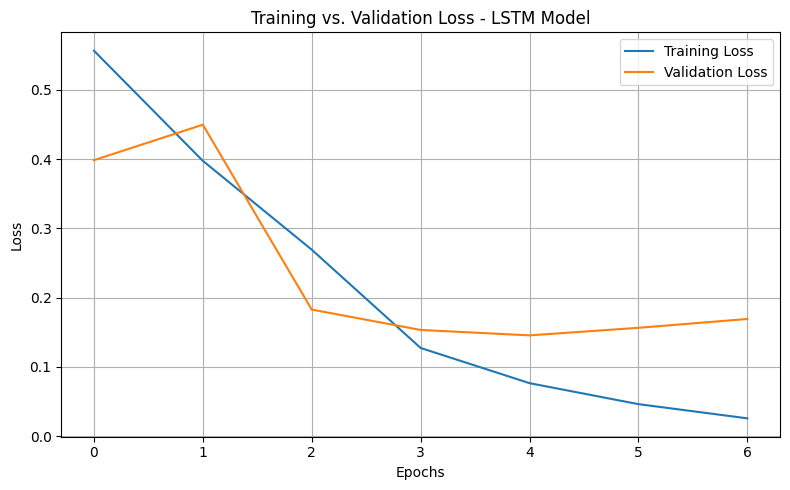

In [13]:
visualize_loss('LSTM', history_lstm.history['loss'], history_lstm.history['val_loss'])

215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
--------------- LSTM Model ---------------
Accuracy: 0.95453
Precision: 0.95827
Recall: 0.95106
F1 Score: 0.95465

Classification Report
              precision    recall  f1-score   support

           0      0.951     0.958     0.954      3408
           1      0.958     0.951     0.955      3453

    accuracy                          0.955      6861
   macro avg      0.955     0.955     0.955      6861
weighted avg      0.955     0.955     0.955      6861

------------------------------
Predict results (ground truth vs predicted)


,y_test,Predicted
65618,1,0
30745,0,0
15116,0,0
53997,0,0
5130,1,0
12556,1,1
58568,1,1
2786,1,1
17729,0,0
18372,0,0


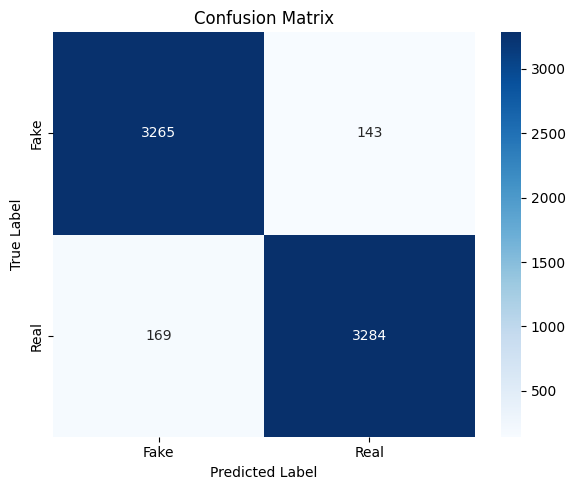

In [14]:
# Load best model and predict
best_lstm = load_model(path_lstm)
y_prob_lstm = best_lstm.predict(X_test_pad)
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

evaluate_model('LSTM', y_test, y_pred_lstm)

### **5.2. BiLSTM**

**BiLSTM (Bidirectional Long Short-Term Memory)**

- **BiLSTM** - tức là mạng LSTM hai chiều. Nó là sự mở rộng của mạng LSTM truyền thống, với khả năng xử lý thông tin theo hai hướng thời gian thay vì chỉ dựa vào ngữ cảnh trước đó như LSTM thường:

    - **Forward**: từ quá khứ đến hiện tại (trái sang phải).

    - **Backward**: từ tương lai đến hiện tại (phải sang trái).

- BiLSTM sử dụng hai mạng LSTM riêng biệt: một mạng đi từ trái sang phải, và một mạng từ phải sang trái trên cùng một chuỗi dữ liệu đầu vào. Trong nhiều bài toán, ý nghĩa của một từ (hoặc phần tử) trong chuỗi phụ thuộc vào cả ngữ cảnh trước và sau nó. Ví dụ:

    > "He banked the boat against the shore."

    $\rightarrow$ Từ “banked” có nghĩa khác nếu câu sau là "He worked at the bank".

**Đối với bài toán Fake New Detection**

- BiLSTM là một lựa chọn phù hợp nhờ khả năng xử lý văn bản theo cả hai chiều. Điều này giúp mô hình hiểu rõ hơn ngữ cảnh tổng thể, đặc biệt trong các trường hợp tin giả sử dụng ngôn ngữ mơ hồ, phủ định, hoặc châm biếm. 

In [15]:
model_bilstm = init_model('bilstm')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 300, 300)            │      17,874,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 300, 300)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 700)                 │       1,822,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 700)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             701 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,698,101 (75.14 MB)

 Trainable params: 19,698,101 (75.14 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model_bilstm, history_bilstm, path_bilstm = train_and_save_model('bilstm', model_bilstm)


----- Training BILSTM -----
Epoch 1/20

Epoch 1: val_loss improved from inf to 0.22775, saving model to checkpoint_bilstm.h5
429/429 - 67s - 156ms/step - accuracy: 0.9018 - loss: 0.2497 - val_accuracy: 0.9086 - val_loss: 0.2277
Epoch 2/20

Epoch 2: val_loss improved from 0.22775 to 0.16393, saving model to checkpoint_bilstm.h5
429/429 - 63s - 147ms/step - accuracy: 0.9434 - loss: 0.1527 - val_accuracy: 0.9397 - val_loss: 0.1639
Epoch 3/20

Epoch 3: val_loss improved from 0.16393 to 0.12863, saving model to checkpoint_bilstm.h5
429/429 - 63s - 147ms/step - accuracy: 0.9790 - loss: 0.0608 - val_accuracy: 0.9557 - val_loss: 0.1286
Epoch 4/20

Epoch 4: val_loss did not improve from 0.12863
429/429 - 62s - 145ms/step - accuracy: 0.9915 - loss: 0.0262 - val_accuracy: 0.9557 - val_loss: 0.1400
Epoch 5/20

Epoch 5: val_loss did not improve from 0.12863
429/429 - 62s - 145ms/step - accuracy: 0.9966 - loss: 0.0114 - val_accuracy: 0.9547 - val_loss: 0.1715
Epoch 5: early stopping
Restoring model

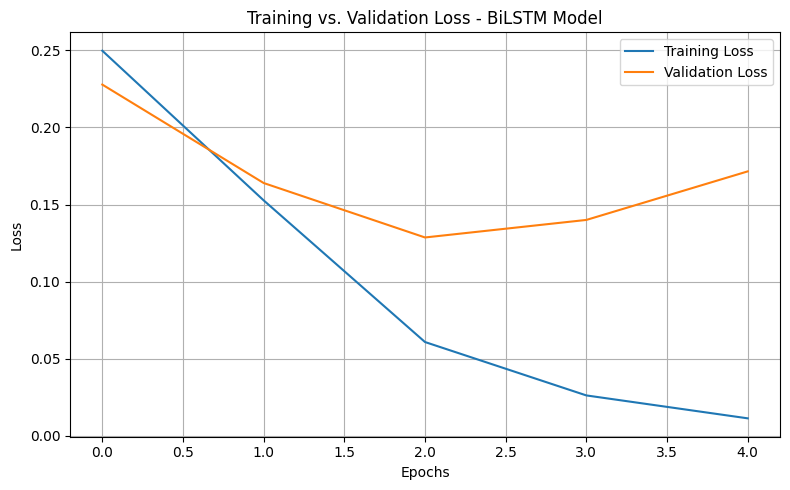

In [17]:
visualize_loss('BiLSTM', history_bilstm.history['loss'], history_bilstm.history['val_loss'])

215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step
--------------- BiLSTM Model ---------------
Accuracy: 0.95569
Precision: 0.96295
Recall: 0.94845
F1 Score: 0.95565

Classification Report
              precision    recall  f1-score   support

           0      0.949     0.963     0.956      3408
           1      0.963     0.948     0.956      3453

    accuracy                          0.956      6861
   macro avg      0.956     0.956     0.956      6861
weighted avg      0.956     0.956     0.956      6861

------------------------------
Predict results (ground truth vs predicted)


,y_test,Predicted
47223,1,1
24314,1,1
24527,0,0
43812,1,1
62332,1,1
44103,1,1
3466,1,1
59214,0,0
40165,1,1
60896,1,1


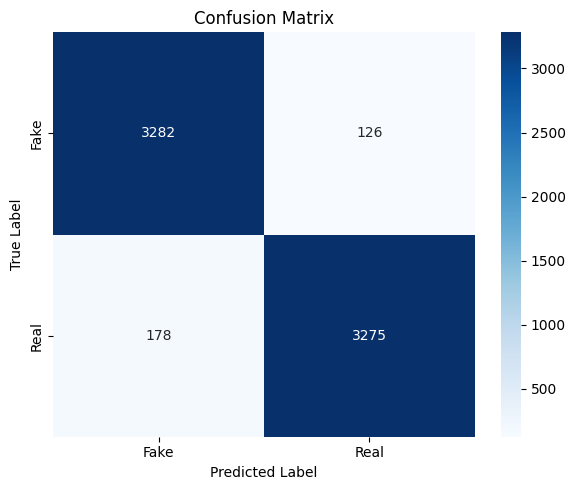

In [18]:
# Load best model and predict
best_bilstm = load_model(path_bilstm)
y_prob_bilstm = best_bilstm.predict(X_test_pad)
y_pred_bilstm = (y_prob_bilstm >= 0.5).astype(int)

evaluate_model('BiLSTM', y_test, y_pred_bilstm)

### **5.3. CNN - BiLSTM**

**BiLSTM (Bidirectional Long Short-Term Memory)**

- **BiLSTM** - tức là mạng LSTM hai chiều. Nó là sự mở rộng của mạng LSTM truyền thống, với khả năng xử lý thông tin theo hai hướng thời gian thay vì chỉ dựa vào ngữ cảnh trước đó như LSTM thường:

    - **Forward**: từ quá khứ đến hiện tại (trái sang phải).

    - **Backward**: từ tương lai đến hiện tại (phải sang trái).

- BiLSTM sử dụng hai mạng LSTM riêng biệt: một mạng đi từ trái sang phải, và một mạng từ phải sang trái trên cùng một chuỗi dữ liệu đầu vào. Trong nhiều bài toán, ý nghĩa của một từ (hoặc phần tử) trong chuỗi phụ thuộc vào cả ngữ cảnh trước và sau nó. Ví dụ:

    > "He banked the boat against the shore."

    $\rightarrow$ Từ “banked” có nghĩa khác nếu câu sau là "He worked at the bank".

**Đối với bài toán Fake New Detection**

- BiLSTM là một lựa chọn phù hợp nhờ khả năng xử lý văn bản theo cả hai chiều. Điều này giúp mô hình hiểu rõ hơn ngữ cảnh tổng thể, đặc biệt trong các trường hợp tin giả sử dụng ngôn ngữ mơ hồ, phủ định, hoặc châm biếm. 

In [19]:
model_combine = init_model('cnn_bilstm')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 300, 300)            │      17,874,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 300, 300)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 300, 32)             │          48,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 150, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 150, 32)             │           5,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 75, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 700)                 │       1,072,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 700)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             701 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,000,885 (72.48 MB)

 Trainable params: 19,000,885 (72.48 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model_combine, history_combine, path_combine = train_and_save_model('cnn_bilstm', model_combine)


----- Training CNN_BILSTM -----
Epoch 1/20

Epoch 1: val_loss improved from inf to 0.13074, saving model to checkpoint_cnn_bilstm.h5
429/429 - 26s - 61ms/step - accuracy: 0.9086 - loss: 0.2277 - val_accuracy: 0.9497 - val_loss: 0.1307
Epoch 2/20

Epoch 2: val_loss improved from 0.13074 to 0.11952, saving model to checkpoint_cnn_bilstm.h5
429/429 - 21s - 48ms/step - accuracy: 0.9700 - loss: 0.0850 - val_accuracy: 0.9566 - val_loss: 0.1195
Epoch 3/20

Epoch 3: val_loss did not improve from 0.11952
429/429 - 19s - 45ms/step - accuracy: 0.9885 - loss: 0.0350 - val_accuracy: 0.9423 - val_loss: 0.1821
Epoch 4/20

Epoch 4: val_loss did not improve from 0.11952
429/429 - 19s - 45ms/step - accuracy: 0.9946 - loss: 0.0166 - val_accuracy: 0.9539 - val_loss: 0.1619
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


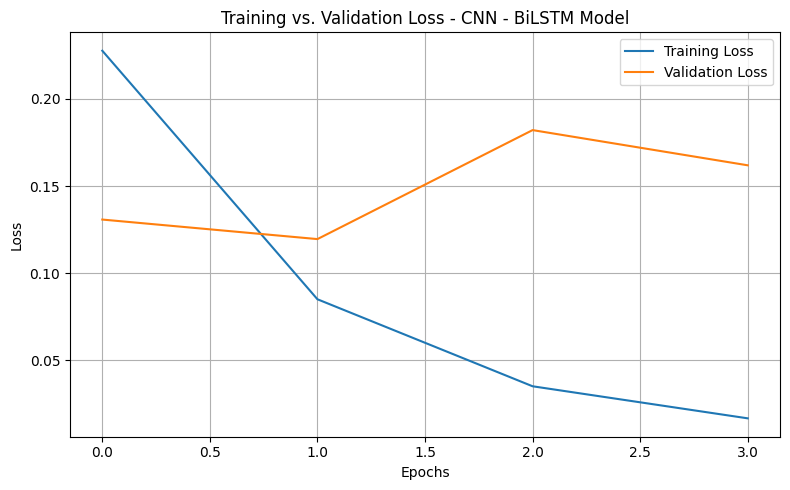

In [21]:
visualize_loss('CNN - BiLSTM', history_combine.history['loss'], history_combine.history['val_loss'])

215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
--------------- CNN - BiLSTM Model ---------------
Accuracy: 0.95846
Precision: 0.95103
Recall: 0.96727
F1 Score: 0.95908

Classification Report
              precision    recall  f1-score   support

           0      0.966     0.950     0.958      3408
           1      0.951     0.967     0.959      3453

    accuracy                          0.958      6861
   macro avg      0.959     0.958     0.958      6861
weighted avg      0.959     0.958     0.958      6861

------------------------------
Predict results (ground truth vs predicted)


,y_test,Predicted
68573,1,1
11768,1,1
65972,1,1
63898,1,1
67736,0,0
42489,0,0
1363,1,1
306,1,1
16062,1,1
34950,0,0


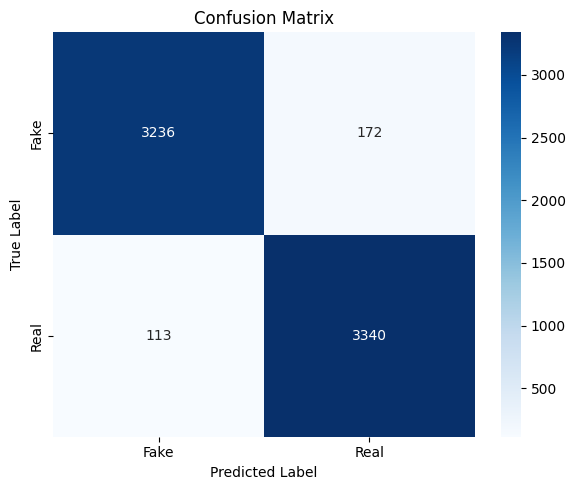

In [22]:
# Load best model and predict
best_combine = load_model(path_combine)
y_prob_combine = best_combine.predict(X_test_pad)
y_pred_combine = (y_prob_combine >= 0.5).astype(int)

evaluate_model('CNN - BiLSTM', y_test, y_pred_combine)

## **06. Transformer**

#### **Objective**

Sau khi đã thử nghiệm mô hình học máy truyền thống (SVM) và mạng học sâu (LSTM, BiLSTM, CNN-BiLSTM), bước tiếp theo là áp dụng các mô hình mạnh nhất hiện nay trong xử lý ngôn ngữ tự nhiên: **Transformer-based models**.

Trong phần này, hai mô hình được sử dụng là:

- **BERT** (Bidirectional Encoder Representations from Transformers)

- **RoBERTa** (A Robustly Optimized BERT Approach)

- **XLNet** (Generalized Autoregressive Pretraining for Language Understanding)

Mục tiêu của bước này là đánh giá hiệu quả của các mô hình Transformer đã được huấn luyện trước (pretrained models) trong việc hiểu và phân loại văn bản tin tức.

#### **Tại sao sử dụng BERT, RoBERTa và XLNet**

**1. Hiểu ngữ cảnh toàn diện và xử lý ngôn ngữ phức tạp**

- BERT, RoBERTa và XLNet đều dựa trên kiến trúc transformer, với khả năng học ngữ cảnh phi tuyến tính, hai chiều (BERT, RoBERTa) hoặc autoregessive đa chiều (XLNet).

- Transformer, nhờ cơ chế attention, có khả năng học được mối liên kết giữa các từ dù chúng cách xa nhau trong chuỗi văn bản. Đây là lợi thế vượt trội so với các mô hình truyền thống (như RNN) khó thực hiện được hiệu quả.

- Điều này đặc biệt quan trọng trong các bài báo dài, nơi thông tin có thể bị rải rác hoặc xếp lớp phức tạp — đặc điểm phổ biến của nội dung tin giả, tuyên truyền, hay mang tính thao túng.

**2. Khai thác sức mạnh của mô hình tiền huấn luyện và dữ liệu quy mô lớn**

- Một ưu điểm quan trọng khác của BERT và RoBERTa là chúng đều là mô hình ngôn ngữ đã pretrained trên những kho dữ liệu văn bản khổng lồ  (Wikipedia, Common Crawl, BookCorpus...) nhờ đó hiểu biết ngôn ngữ chung rất sâu rộng.

- Khi áp dụng cho bài toán phân loại tin giả, thay vì phải huấn luyện từ đầu (scratch), chỉ cần fine-tune mô hình trên tập dữ liệu chuyên biệt của bài toán → tiết kiệm chi phí và thời gian, vẫn đảm bảo hiệu năng cao.

**3. So sánh model**

- RoBERTa cải tiến quá trình huấn luyện của BERT bằng cách loại bỏ masking static và sử dụng nhiều dữ liệu hơn.

- XLNet kết hợp ưu điểm của autoregressive (như GPT) và autoencoding (như BERT) để tạo ra một mô hình hiệu quả hơn về modeling order và dependency.

In [5]:
# ------------ 1. Tokenizer ------------
def tokenize_data(texts, model_name, max_length=256):
    # Chọn tokenizer phù hợp
    if model_name=='roberta-base':
        tokenizer = RobertaTokenizer.from_pretrained(model_name, use_fast=True)
    elif model_name=='bert-base-uncased':
        tokenizer = BertTokenizer.from_pretrained(model_name, use_fast=True)
    elif model_name=='xlnet-base-cased':
        tokenizer = XLNetTokenizer.from_pretrained(model_name, use_fast=True)
    else:
        raise ValueError("Unsupported model_name. Only 'bert', 'roberta' or 'xlnet are supported.")

    # Token hóa dữ liệu
    encoding = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
    )
    return encoding

In [6]:
# ------------ 2. Dataset ------------
class FakeNewDataset(Dataset):
    def __init__(self, encodings, labels=None):
        super().__init__()
        self.encodings = encodings
        self.labels = labels 
    
    def __len__(self):
        return len(self.encodings['input_ids'])
    
    def __getitem__(self, index):
        item = {key: torch.tensor(val[index]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[index])
        return item

In [7]:
# ------------ 3. Model ------------
def get_model(model_name, num_labels=2, dropout=0.1):
    # Load config (bert, roberta, xlnet, v.v.)
    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=num_labels,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    )

    # Load model 
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config
    )
    return model

In [8]:
# -------- 4. Model --------
learning_rate = 2e-5
n_epoch = 5
patience = 2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Trainer:
    def __init__(self, model, train_loader, val_loader, lr, epochs, patience, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.epochs = epochs
        self.device = device
        self.patience = patience
        self.train_loss_history = []
        self.val_loss_history = []
        self.optimizer = AdamW(self.model.parameters(), lr=lr)
        self.model.to(self.device)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        loop = tqdm(self.train_loader, desc="\tTraining", leave=False)
        for batch in loop:
            batch = {k: v.to(self.device) for k, v in batch.items()}
            outputs = self.model(**batch)
            loss = outputs.loss
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(self.train_loader)
        return avg_loss

    def evaluate(self):
        self.model.eval()
        all_preds = []
        all_labels = []
        total_loss = 0.0

        loop = tqdm(self.val_loader, desc="\tEvaluating", leave=False)
        with torch.no_grad():
            for batch in loop:
                batch = {k: v.to(self.device) for k, v in batch.items()}
                outputs = self.model(**batch)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch['labels'].cpu().numpy())
                loss = outputs.loss
                total_loss += loss.item()
                loop.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(self.val_loader)
        acc = accuracy_score(all_labels, all_preds)
        return acc, avg_loss

    def train(self):
        best_loss = float('inf')
        patience_counter = 0.0
        for epoch in range(1, self.epochs+1):
            print(f"Epoch {epoch}/{self.epochs}")
            train_loss = self.train_epoch()
            val_acc, val_loss = self.evaluate()

            self.train_loss_history.append(train_loss)
            self.val_loss_history.append(val_loss)

            print(f"\tTrain loss = {train_loss:.5f} | val_loss = {val_loss:.5f}")
            print(f"\tVal accuracy: {val_acc}")

            if val_loss < best_loss:
                best_loss = val_loss
                patience_counter = 0
                torch.save(self.model.state_dict(), f"{self.model.__class__.__name__}_best.pt")
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping triggered.")
                    break

    def inference_model(self, dataloader):
        self.model.eval()
        all_preds = []

        with torch.no_grad():
            for batch in tqdm(dataloader, desc="Inferencing"):
                batch = {k: v.to(self.device) for k, v in batch.items() if k != 'labels'}
                outputs = self.model(**batch)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())

        return all_preds

In [9]:
# -------- 5. Prepare data & Run model --------
X_train_trans, X_val_trans, X_test_trans = [
    df['clean_text_trans'].tolist() for df in [X_train, X_val, X_test]
]

y_train_trans, y_val_trans, y_test_trans = [
    y.tolist() for y in [y_train, y_val, y_test]
]

def run_model(model_name, batch_size):

    train_encodings, val_encodings, test_encodings = [
        tokenize_data(data, model_name)
        for data in [X_train_trans, X_val_trans, X_test_trans]
    ]

    train_dataset = FakeNewDataset(train_encodings, y_train_trans)
    val_dataset = FakeNewDataset(val_encodings, y_val_trans)
    test_dataset = FakeNewDataset(test_encodings)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    model = get_model(model_name)

    print(f"-"*50)
    print(f"TRAINING MODEL: {model_name}".center(50))
    print(f"-"*50)
    trainer = Trainer(
        model, 
        train_loader, 
        val_loader, 
        lr=learning_rate,
        epochs=n_epoch, 
        patience=patience, 
        device=device
    )
    trainer.train()
    
    print(f"-"*50)
    print(f"\tINFERENCE MODEL")
    print(f"-"*50)
    y_pred = trainer.inference_model(test_loader)

    return model, trainer, y_pred

### **6.1. Bert Model**

In [10]:
model_name_bert = 'bert-base-uncased'
model_bert, trainer_bert, y_pred_bert = run_model(model_name=model_name_bert, batch_size=32)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

	Train loss = 0.07278 | val_loss = 0.04521
	Val accuracy: 0.9826530612244898
Epoch 2/5


	Train loss = 0.02043 | val_loss = 0.02548
	Val accuracy: 0.9918367346938776
Epoch 3/5


	Train loss = 0.01075 | val_loss = 0.06748
	Val accuracy: 0.9811953352769679
Epoch 4/5


	Train loss = 0.00709 | val_loss = 0.04471
	Val accuracy: 0.9895043731778426
Early stopping triggered.
--------------------------------------------------
	INFERENCE MODEL
--------------------------------------------------


Inferencing: 100%|██████████| 215/215 [00:51<00:00,  4.21it/s]


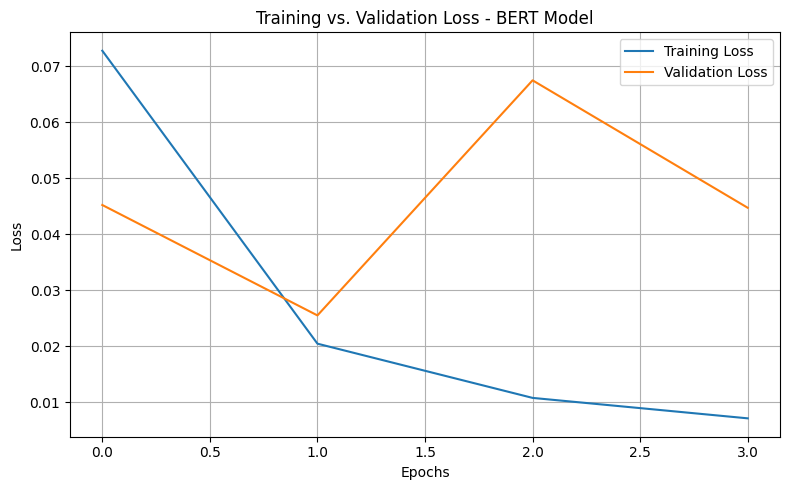

In [11]:
visualize_loss(
    model_name="BERT", 
    train_loss=trainer_bert.train_loss_history, 
    val_loss=trainer_bert.val_loss_history
)

--------------- BERT Model ---------------
Accuracy: 0.98703
Precision: 0.98085
Recall: 0.99363
F1 Score: 0.98720

Classification Report
              precision    recall  f1-score   support

           0      0.993     0.980     0.987      3408
           1      0.981     0.994     0.987      3453

    accuracy                          0.987      6861
   macro avg      0.987     0.987     0.987      6861
weighted avg      0.987     0.987     0.987      6861

------------------------------
Predict results (ground truth vs predicted)


,y_test,Predicted
65618,1,0
30745,0,0
15116,0,0
53997,0,0
5130,1,1
12556,1,1
58568,1,1
2786,1,1
17729,0,0
18372,0,0


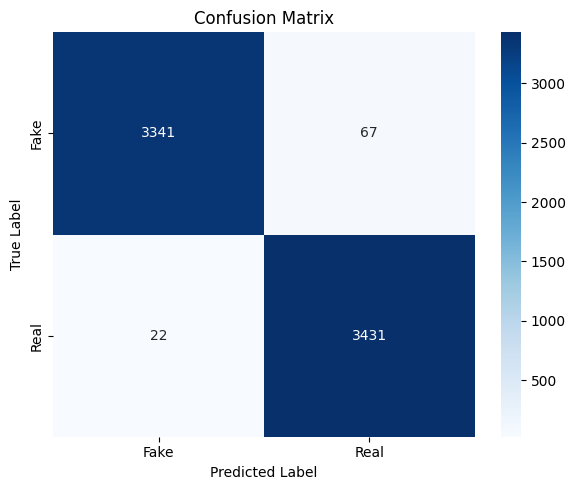

In [22]:
# Evaluate model
evaluate_model('BERT', y_test, y_pred_bert)

### **6.2. RoBERTa Model**

In [23]:
model_name_roberta = 'roberta-base'
model_roberta, trainer_roberta, y_pred_roberta = run_model(model_name_roberta, batch_size=32)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

...

	Train loss = 0.01815 | val_loss = 0.04316
	Val accuracy: 0.9877551020408163
Epoch 3/5


	Train loss = 0.01110 | val_loss = 0.02091
	Val accuracy: 0.993002915451895
Epoch 4/5


	Train loss = 0.00871 | val_loss = 0.03050
	Val accuracy: 0.9950437317784256
Epoch 5/5


	Train loss = 0.00640 | val_loss = 0.02553
	Val accuracy: 0.9934402332361516
Early stopping triggered.
--------------------------------------------------
	INFERENCE MODEL
--------------------------------------------------


Inferencing: 100%|██████████| 215/215 [00:50<00:00,  4.24it/s]


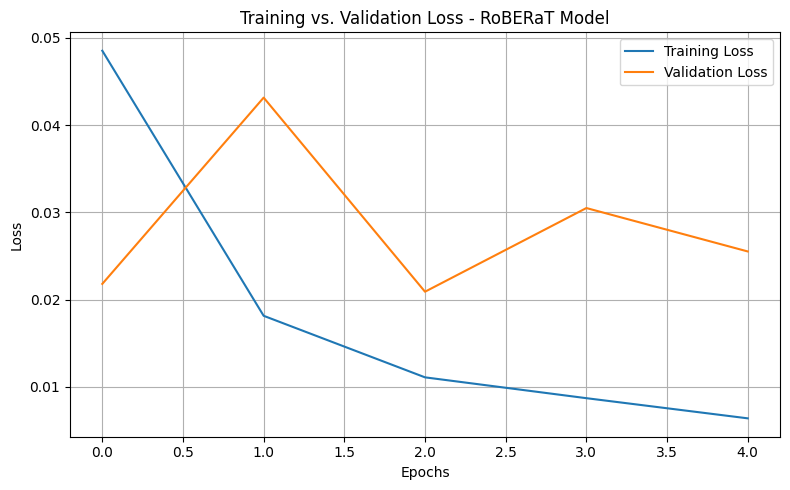

In [24]:
visualize_loss(
    model_name="RoBERaT", 
    train_loss=trainer_roberta.train_loss_history, 
    val_loss=trainer_roberta.val_loss_history
)

--------------- roberta-base Model ---------------
Accuracy: 0.99373
Precision: 0.99708
Recall: 0.99044
F1 Score: 0.99375

Classification Report
              precision    recall  f1-score   support

           0      0.990     0.997     0.994      3408
           1      0.997     0.990     0.994      3453

    accuracy                          0.994      6861
   macro avg      0.994     0.994     0.994      6861
weighted avg      0.994     0.994     0.994      6861

------------------------------
Predict results (ground truth vs predicted)


,y_test,Predicted
47223,1,1
24314,1,1
24527,0,0
43812,1,1
62332,1,1
44103,1,1
3466,1,1
59214,0,0
40165,1,1
60896,1,1


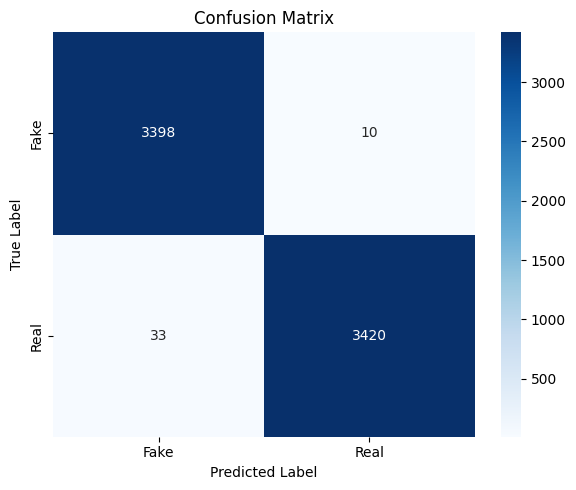

In [25]:
# Evaluate model
evaluate_model(model_name_roberta, y_test, y_pred_roberta)

### **6.3. XLNet Model**

In [10]:
model_name_xlnet = 'xlnet-base-cased'
model_xlnet, trainer_xlnet, y_pred_xlnet = run_model(model_name=model_name_xlnet, batch_size=32)

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

	Train loss = 0.05482 | val_loss = 0.02382
	Val accuracy: 0.9921282798833819
Epoch 2/5


	Train loss = 0.01974 | val_loss = 0.03211
	Val accuracy: 0.989067055393586
Epoch 3/5


	Train loss = 0.01269 | val_loss = 0.03203
	Val accuracy: 0.9916909620991253
Early stopping triggered.
--------------------------------------------------
	INFERENCE MODEL
--------------------------------------------------


Inferencing: 100%|██████████| 215/215 [01:57<00:00,  1.83it/s]


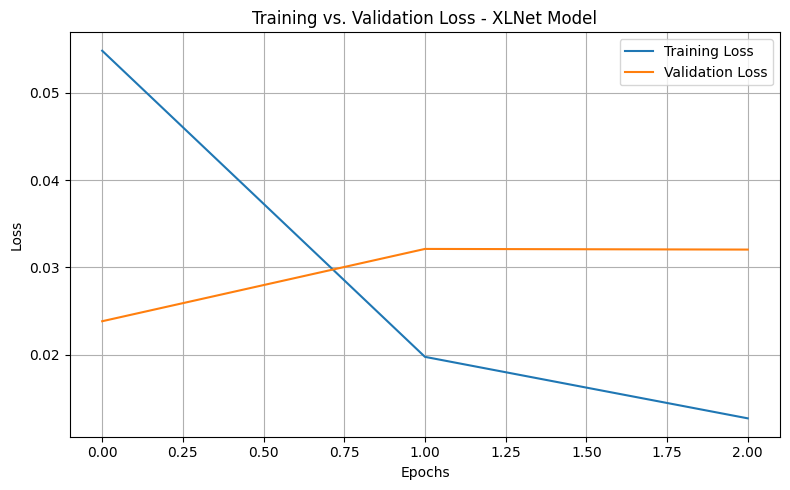

In [11]:
visualize_loss(
    model_name="XLNet", 
    train_loss=trainer_xlnet.train_loss_history, 
    val_loss=trainer_xlnet.val_loss_history
)

--------------- xlnet Model ---------------
Accuracy: 0.99155
Precision: 0.98905
Recall: 0.99421
F1 Score: 0.99162

Classification Report
              precision    recall  f1-score   support

           0      0.994     0.989     0.991      3408
           1      0.989     0.994     0.992      3453

    accuracy                          0.992      6861
   macro avg      0.992     0.992     0.992      6861
weighted avg      0.992     0.992     0.992      6861

------------------------------
Predict results (ground truth vs predicted)


,y_test,Predicted
65618,1,0
30745,0,0
15116,0,0
53997,0,0
5130,1,1
12556,1,1
58568,1,1
2786,1,1
17729,0,0
18372,0,0


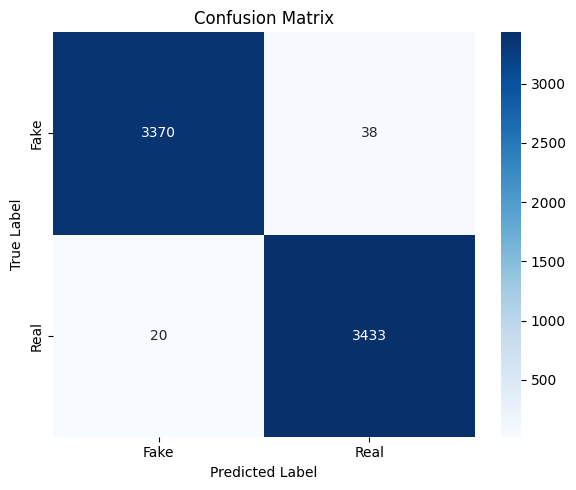

In [15]:
# Evaluate model
evaluate_model('xlnet', y_test, y_pred_xlnet)

## **7. Evaluation and Comparison**

<table>
  <tr>
    <th style="width: 20%;">Model</th>
    <th style="width: 20%;">Accuracy</th>
    <th style="width: 20%;">Precision</th>
    <th style="width: 20%;">Recall</th>
    <th style="width: 20%;">F1-score</th>
  </tr>
  <tr>
    <td>Linear SVM</td><td>0.963</td><td>0.964</td><td>0.963</td><td>0.963</td>
  </tr>
  <tr>
    <td>LSTM</td><td>0.955</td><td>0.958</td><td>0.951</td><td>0.955</td>
  </tr>
  <tr>
    <td>BiLSTM</td><td>0.956</td><td>0.963</td><td>0.948</td><td>0.956</td>
  </tr>
  <tr>
    <td>CNN-BiLSTM</td><td>0.958</td><td>0.951</td><td>0.967</td><td>0.959</td>
  </tr>
  <tr>
    <td><b>BERT</b></td><td>0.987</td><td>0.981</td><td>0.994</td><td>0.987</td>
  </tr>
  <tr>
    <td><b>RoBERTa</b></td><td><b>0.994</b></td><td><b>0.998</b></td><td>0.990</td><td><b>0.994</b></td>
  </tr>
  <tr>
    <td><b>XLNet</b></td><td>0.992</td><td>0.989</td><td><b>0.994</b></td><td>0.992</td>
  </tr>
</table>


#### **1. Đánh giá hiệu suất và nhận xét tổng quan**

Sau khi triển khai toàn bộ các mô hình từ học máy truyền thống, học sâu đến các mô hình Transformer hiện đại, kết quae thu được cho thấy sự khác biệt rõ về hiệu suất giữa các nhóm phương pháp.

##### **Mô hình học máy truyền thống (Linear SVM)** 

- Mô hình đạt kết quả rất tốt, với Accuracy và F1-score đều ở mức 0.963.

    $\rightarrow$ Điều này cho thấy ngay cả với các phương pháp không cần kiến trúc sâu, việc xử lý văn bản hiệu quả (như dùng TF-IDF) vẫn mang lại độ chính xác rất cao.

- Hiệu suất đồng đều trên các chỉ số cho thấy mô hình xử lý tốt tính chất cân bằng của tập dữ liệu, mặc dù thiếu khả năng nắm bắt các mẫu ngôn ngữ phức tạp hơn.

#### **Mô hình học sâu (LSTM, BiLSTM, CNN-BiLSTM)** 

- Hiệu suất khá đồng đều, dao động từ 0.955 đến 0.959 về F1-score. BiLSTM hiệu suất nhỉnh hơn so với LSTM, cho thấy khả năng nắm bắt được ngữ cảnh hai chiều. 

- CNN-BiLSTM nổi bật hơn do khả năng kết hợp giữa trích xuất đặc trưng cục bộ (CNN) và hiểu ngữ cảnh dài hạn.

#### **Mô hình Transformer (BERT, RoBERTa, XLNet)** 

- Các mô hình transformer thể hiện hiệu suất vượt trội:

    - RoBERTa đạt F1-score 0.994 – là mô hình tốt nhất so bất kỳ mô hình nào.

    - BERT đạt tới 0.987, và XLNet cũng đạt được hiệu suất rất cao.

    $\rightarrow$ Minh chứng rõ ràng cho lợi thế của các mô hình ngôn ngữ tiền huấn luyện: khả năng hiểu ngữ cảnh sâu sắc, nắm bắt cấu trúc câu phức tạp, và học được các mẫu ngôn ngữ ngầm trong tin giả mà các mô hình truyền thống khó nhận ra.

#### **Kết luận**

Từ kết quả thực nghiệm, có thể thấy:

- `Transformer-based models` vượt trội hơn hẳn so với các phương pháp còn lại, cả về độ chính xác và độ ổn định. Nhóm mô hình này đặc biệt phù hợp với các tác vụ yêu cầu hiểu sâu ngữ nghĩa như Fake News Detection – nơi ngôn ngữ thường mang tính đánh lừa, ngụ ý hoặc ngữ cảnh ngầm.

- Các mô hình như SVM hoặc CNN-BiLSTM vẫn cho kết quả rất tốt, với chi phí tính toán thấp hơn nhiều. Chúng phù hợp trong các kịch bản thực tế có giới hạn tài nguyên hoặc yêu cầu xử lý nhanh.